In [2]:
# tarflow.py
from __future__ import annotations
import math
from dataclasses import dataclass
from typing import Optional, Tuple, List

import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
def make_causal_mask(n_tokens: int, device: torch.device) -> torch.Tensor:
    """
    Attention mask for causal self-attention.
    Shape: [n_tokens, n_tokens]
    Masked (future) positions are set to -inf.
    """
    # upper triangular (above diagonal) = future positions
    mask = torch.full((n_tokens, n_tokens), float("-inf"), device=device)
    mask = torch.triu(mask, diagonal=1)
    return mask

In [4]:
class TransformerBlock(nn.Module):
    """
    Minimal pre-norm Transformer block:
    LN -> MHA -> residual
    LN -> FFN -> residual
    """
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads, dropout=dropout, batch_first=True
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attn_mask: torch.Tensor) -> torch.Tensor:
        # x: [B, N, d_model], attn_mask: [N, N]
        h = self.ln1(x)
        a, _ = self.attn(h, h, h, attn_mask=attn_mask, need_weights=False)
        x = x + self.dropout(a)

        h = self.ln2(x)
        f = self.ff(h)
        x = x + self.dropout(f)
        return x

In [5]:
class CausalTransformer(nn.Module):
    """
    Causal Transformer over a short sequence (here N=2 tokens).
    """
    def __init__(
        self,
        n_tokens: int,
        token_dim: int,
        d_model: int = 32,
        n_heads: int = 4,
        n_layers: int = 2,
        d_ff: Optional[int] = None,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.n_tokens = n_tokens
        self.token_dim = token_dim
        self.d_model = d_model

        if d_ff is None:
            d_ff = 4 * d_model

        self.in_proj = nn.Linear(token_dim, d_model)

        # learned positional embeddings (N is tiny)
        self.pos_emb = nn.Parameter(torch.zeros(n_tokens, d_model))
        nn.init.normal_(self.pos_emb, mean=0.0, std=0.02)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.out_ln = nn.LayerNorm(d_model)

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        """
        tokens: [B, N, token_dim]
        returns: [B, N, d_model]
        """
        B, N, D = tokens.shape
        assert N == self.n_tokens and D == self.token_dim

        h = self.in_proj(tokens)  # [B, N, d_model]
        h = h + self.pos_emb.unsqueeze(0)  # broadcast over batch

        attn_mask = make_causal_mask(self.n_tokens, device=tokens.device)

        for blk in self.blocks:
            h = blk(h, attn_mask=attn_mask)

        h = self.out_ln(h)
        return h


In [6]:
class TARFlowBlock(nn.Module):
    """
    One TARFlow block for 2D:
    - optional permutation (swap dims)
    - causal transformer predicts mu and log_s per token
    - autoregressive affine transform

    We implement forward: x -> z with:
        z = (x - mu) * exp(-log_s)
        log_det = -sum(log_s)

    Inverse (sampling) is sequential in token order:
        x_i = mu_i(x_<i) + exp(log_s_i(x_<i)) * z_i
    """
    def __init__(
        self,
        dim: int = 2,
        d_model: int = 32,
        n_heads: int = 4,
        n_layers: int = 2,
        dropout: float = 0.0,
        clamp_log_s: float = 5.0,
        reverse: bool = False,
    ):
        super().__init__()
        assert dim == 2, "This TARFlowBlock implementation is specialized for dim=2 (two moons)."
        self.dim = dim
        self.n_tokens = dim         # N=2 tokens
        self.token_dim = 1          # scalar per token
        self.reverse = reverse
        self.clamp_log_s = clamp_log_s

        self.transformer = CausalTransformer(
            n_tokens=self.n_tokens,
            token_dim=self.token_dim,
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            dropout=dropout,
        )
        self.param_head = nn.Linear(d_model, 2)  # -> (mu, log_s)

        # learned "start token" value (so token 0 params are unconditional)
        self.sos = nn.Parameter(torch.zeros(1, 1, self.token_dim))
        nn.init.normal_(self.sos, mean=0.0, std=0.02)

    def _permute(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B,2]
        if not self.reverse:
            return x
        return torch.stack([x[:, 1], x[:, 0]], dim=1)

    def _unpermute(self, x: torch.Tensor) -> torch.Tensor:
        # swap back (same operation)
        return self._permute(x)

    def _tokens_from_x(self, x: torch.Tensor) -> torch.Tensor:
        """
        Build AR transformer inputs by shifting x right:
        token0 sees SOS
        token1 sees x1
        This allows params for x2 to depend on x1.
        """
        B = x.size(0)
        tokens = torch.zeros(B, 2, 1, device=x.device, dtype=x.dtype)
        tokens[:, 0:1, :] = self.sos.expand(B, -1, -1)   # token 0 = SOS
        tokens[:, 1, 0] = x[:, 0]                        # token 1 = x1 (context for x2)
        return tokens


    def _params(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        x: [B,2] (already permuted in the block's order)
        returns mu, log_s: both [B,2]
        """
        tokens = self._tokens_from_x(x)                   # [B,2,1]
        h = self.transformer(tokens)                      # [B,2,d_model]
        params = self.param_head(h)                       # [B,2,2]
        mu = params[..., 0]                               # [B,2]
        log_s = params[..., 1].clamp(-self.clamp_log_s, self.clamp_log_s)
        return mu, log_s

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        x -> z
        returns:
            z: [B,2]
            log_det: [B]
        """
        x = self._permute(x)
        mu, log_s = self._params(x)

        z = (x - mu) * torch.exp(-log_s)                  # [B,2]
        log_det = (-log_s).sum(dim=1)                     # [B]

        z = self._unpermute(z)
        return z, log_det

    @torch.no_grad()
    def inverse(self, z: torch.Tensor) -> torch.Tensor:
        z = self._permute(z)
        x = torch.zeros_like(z)

        # Step 1: get params for x1 (unconditional)
        mu, log_s = self._params(x)  # token0 uses SOS
        x[:, 0] = mu[:, 0] + torch.exp(log_s[:, 0]) * z[:, 0]

        # Step 2: get params for x2 (conditioned on x1)
        mu, log_s = self._params(x)  # token1 now sees x1 via shifted tokens
        x[:, 1] = mu[:, 1] + torch.exp(log_s[:, 1]) * z[:, 1]

        x = self._unpermute(x)
        return x


In [7]:
class TARFlow(nn.Module):
    """
    Stack of TARFlowBlocks + standard normal base.
    """
    def __init__(
        self,
        dim: int = 2,
        n_blocks: int = 5,
        d_model: int = 32,
        n_heads: int = 4,
        n_layers: int = 2,
        dropout: float = 0.0,
        clamp_log_s: float = 5.0,
    ):
        super().__init__()
        self.dim = dim
        self.n_blocks = n_blocks

        blocks: List[nn.Module] = []
        for b in range(n_blocks):
            blocks.append(TARFlowBlock(
                dim=dim,
                d_model=d_model,
                n_heads=n_heads,
                n_layers=n_layers,
                dropout=dropout,
                clamp_log_s=clamp_log_s,
                reverse=(b % 2 == 1),   # alternate order by reversing
            ))
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        x -> z through all blocks
        returns z, total_log_det
        """
        log_det_total = torch.zeros(x.size(0), device=x.device)
        z = x
        for blk in self.blocks:
            z, log_det = blk(z)
            log_det_total = log_det_total + log_det
        return z, log_det_total

    def log_prob(self, x: torch.Tensor) -> torch.Tensor:
        """
        log p(x) = log p(z) + log|det dz/dx|
        """
        z, log_det = self.forward(x)
        # standard normal log prob
        log_base = -0.5 * (z ** 2).sum(dim=1) - 0.5 * self.dim * math.log(2 * math.pi)
        return log_base + log_det

    @torch.no_grad()
    def sample(self, n: int, device: Optional[torch.device] = None) -> torch.Tensor:
        if device is None:
            device = next(self.parameters()).device
        z = torch.randn(n, self.dim, device=device)
        x = z
        # invert blocks in reverse order
        for blk in reversed(self.blocks):
            x = blk.inverse(x)
        return x


In [8]:
import torch
from torch.optim import Adam

def train_flow(model, train_loader, test_loader=None, epochs=50, lr=1e-3, device="cpu"):
    model.to(device)
    opt = Adam(model.parameters(), lr=lr)

    for ep in range(1, epochs + 1):
        model.train()
        total = 0.0
        n = 0
        for x, *_ in train_loader:   # if your loader returns (x,y) just ignore y
            x = x.to(device).float()
            loss = -model.log_prob(x).mean()

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            total += loss.item() * x.size(0)
            n += x.size(0)

        train_nll = total / n

        if test_loader is not None:
            model.eval()
            total = 0.0
            n = 0
            with torch.no_grad():
                for x, *_ in test_loader:
                    x = x.to(device).float()
                    loss = -model.log_prob(x).mean()
                    total += loss.item() * x.size(0)
                    n += x.size(0)
            test_nll = total / n
            print(f"Epoch {ep:03d} | Train NLL: {train_nll:.4f} | Test NLL: {test_nll:.4f}")
        else:
            print(f"Epoch {ep:03d} | Train NLL: {train_nll:.4f}")


In [9]:
from sklearn import datasets
import torch

def get_moons_unconditional(n_samples=5000, noise=0.1, batch_size=256, test_split=0.2, seed=42):
    X, _ = datasets.make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    X = torch.tensor(X, dtype=torch.float32)

    # split
    n_test = int(test_split * n_samples)
    idx = torch.randperm(n_samples)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    X_train = X[train_idx]
    X_test  = X[test_idx]

    train_ds = torch.utils.data.TensorDataset(X_train)
    test_ds  = torch.utils.data.TensorDataset(X_test)

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, X_train, X_test


def get_moons_conditional(n_samples=5000, noise=0.1, batch_size=256, test_split=0.2, seed=42):
    X, y = datasets.make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.nn.functional.one_hot(torch.tensor(y), num_classes=2).float()

    # split
    n_test = int(test_split * n_samples)
    idx = torch.randperm(n_samples)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]

    train_ds = torch.utils.data.TensorDataset(X_train, y_train)
    test_ds  = torch.utils.data.TensorDataset(X_test, y_test)

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, X_train, X_test, y_train, y_test


In [10]:
train_loader, test_loader, X_train, X_test = get_moons_unconditional()

# X_uncond: [N,2], train_loader returns batches of x
tarflow = TARFlow(
    dim=2,
    n_blocks=5,
    d_model=64,
    n_heads=4,
    n_layers=5,
    dropout=0.0,
)

train_flow(tarflow, train_loader=train_loader, test_loader=test_loader, epochs=100, lr=1e-4, device="cpu")

samples = tarflow.sample(2000)


Epoch 001 | Train NLL: 3.4280 | Test NLL: 1.9744
Epoch 002 | Train NLL: 1.8917 | Test NLL: 1.8133
Epoch 003 | Train NLL: 2.0038 | Test NLL: 1.8662
Epoch 004 | Train NLL: 1.7425 | Test NLL: 1.6488
Epoch 005 | Train NLL: 1.6339 | Test NLL: 1.5660
Epoch 006 | Train NLL: 1.6622 | Test NLL: 1.7240
Epoch 007 | Train NLL: 1.6778 | Test NLL: 1.6014
Epoch 008 | Train NLL: 1.5634 | Test NLL: 1.5195
Epoch 009 | Train NLL: 1.5392 | Test NLL: 1.5420
Epoch 010 | Train NLL: 1.6360 | Test NLL: 1.4777
Epoch 011 | Train NLL: 1.5354 | Test NLL: 1.4385
Epoch 012 | Train NLL: 1.5289 | Test NLL: 1.7536
Epoch 013 | Train NLL: 1.5682 | Test NLL: 1.4222
Epoch 014 | Train NLL: 1.4794 | Test NLL: 1.4837
Epoch 015 | Train NLL: 1.4735 | Test NLL: 1.6278
Epoch 016 | Train NLL: 1.5246 | Test NLL: 1.3601
Epoch 017 | Train NLL: 1.4787 | Test NLL: 1.4332
Epoch 018 | Train NLL: 1.4592 | Test NLL: 1.4216
Epoch 019 | Train NLL: 1.4547 | Test NLL: 1.4955
Epoch 020 | Train NLL: 1.4746 | Test NLL: 1.3576
Epoch 021 | Train NL

In [11]:
tarflow.eval()

with torch.no_grad():
    gen_X = tarflow.sample(2000).cpu()


In [12]:
import matplotlib.pyplot as plt

def plot_moons(real_X, gen_X, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Real data
    axes[0].scatter(
        real_X[:, 0], real_X[:, 1],
        s=10, alpha=0.6
    )
    axes[0].set_title(f"Real Two Moons {title_suffix}")
    axes[0].set_aspect("equal")

    # Generated data
    axes[1].scatter(
        gen_X[:, 0], gen_X[:, 1],
        s=10, alpha=0.6
    )
    axes[1].set_title(f"TARFlow Samples {title_suffix}")
    axes[1].set_aspect("equal")

    for ax in axes:
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-1.5, 2.0)
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


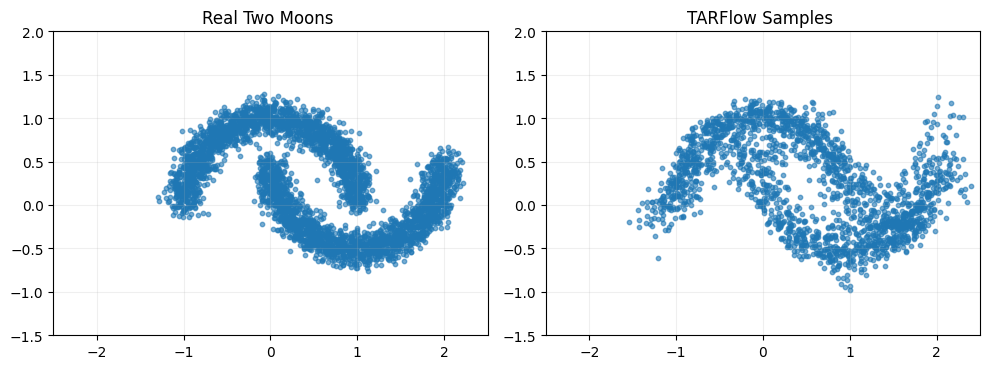

In [13]:
plot_moons(X_train, gen_X)


In [14]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

def count_params(model):
    return sum(p.numel() for p in model.parameters())

@torch.no_grad()
def eval_nll(model, dataloader, device=None):
    """
    Works with:
      - flow models that return (z, log_det) via model(x) or model(x,y)
      - TARFlow-style models that implement .log_prob(x) (or .log_prob(x,y) if you add conditional later)
    Returns average NLL (lower is better).
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    total_nll = 0.0
    total_n = 0

    for batch in dataloader:
        x = batch[0].to(device)

        # TARFlow path: if model has log_prob
        if hasattr(model, "log_prob"):
            # unconditional
            lp = model.log_prob(x)   # [B]
            nll = (-lp)
        else:
            # your existing path: model returns (z, log_det)
            D = x.shape[1]
            const = 0.5 * D * torch.log(torch.tensor(2 * torch.pi, device=device))

            if getattr(model, "condition_size", None) is not None:
                y = batch[1].to(device)
                z, log_det = model(x, y)
            else:
                z, log_det = model(x)

            nll = const + 0.5 * torch.sum(z**2, dim=1) - log_det

        total_nll += nll.sum().item()
        total_n += x.size(0)

    return total_nll / total_n


def _rbf_kernel(x, y, sigma):
    x_norm = (x**2).sum(dim=1, keepdim=True)
    y_norm = (y**2).sum(dim=1, keepdim=True).t()
    dist2 = x_norm + y_norm - 2.0 * x @ y.t()
    return torch.exp(-dist2 / (2.0 * sigma**2))

@torch.no_grad()
def mmd_rbf(x, y, sigma=None, max_pts=1000):
    x = x.detach()
    y = y.detach()

    if sigma is None:
        z = torch.cat([x, y], dim=0)
        if z.size(0) > max_pts:
            idx = torch.randperm(z.size(0))[:max_pts]
            z = z[idx]
        z_norm = (z**2).sum(dim=1, keepdim=True)
        dist2 = z_norm + z_norm.t() - 2.0 * z @ z.t()
        dist2 = dist2[torch.triu(torch.ones_like(dist2), diagonal=1) == 1]
        median_dist = torch.sqrt(torch.median(dist2).clamp(min=1e-12))
        sigma = median_dist.item()

    Kxx = _rbf_kernel(x, x, sigma)
    Kyy = _rbf_kernel(y, y, sigma)
    Kxy = _rbf_kernel(x, y, sigma)

    n = x.size(0)
    m = y.size(0)
    if n > 1:
        Kxx = Kxx - torch.diag(torch.diag(Kxx))
        mmd_xx = Kxx.sum() / (n * (n - 1))
    else:
        mmd_xx = 0.0

    if m > 1:
        Kyy = Kyy - torch.diag(torch.diag(Kyy))
        mmd_yy = Kyy.sum() / (m * (m - 1))
    else:
        mmd_yy = 0.0

    mmd_xy = Kxy.mean()
    return float((mmd_xx + mmd_yy - 2.0 * mmd_xy).item())

@torch.no_grad()
def sampling_speed(model, sample_fn, n_samples=2000, n_repeats=20, warmup=5):
    model.eval()
    for _ in range(warmup):
        _ = sample_fn(n_samples)

    t0 = time.perf_counter()
    for _ in range(n_repeats):
        _ = sample_fn(n_samples)
    t1 = time.perf_counter()

    total = n_samples * n_repeats
    return total / (t1 - t0)


In [15]:
device = next(tarflow.parameters()).device

def sample_tarflow_uncond(n):
    return tarflow.sample(n, device=device).to(device)


In [16]:


train_loader, uncond_test_loader, X_train, X_test_uncond = get_moons_unconditional()


rows = []

# TARFlow (unconditional)
nll = eval_nll(tarflow, uncond_test_loader, device=device)
gen = sample_tarflow_uncond(2000)
mmd = mmd_rbf(gen, X_test_uncond.to(device)[:2000])
sps = sampling_speed(tarflow, sample_tarflow_uncond, n_samples=2000)

rows.append({
    "Model": "TARFlow (uncond)",
    "Params": count_params(tarflow),
    "Test NLL ↓": nll,
    "MMD² ↓": mmd,
    "Sampling (samples/s) ↑": sps
})

tarflow_df = pd.DataFrame(rows)
tarflow_df


,Model,Params,Test NLL ↓,MMD² ↓,Sampling (samples/s) ↑
0,TARFlow (uncond),1252175,1.24623,0.001912,2592.538255


In [17]:
import pandas as pd
import torch

def run_tarflow_ablation(configs, train_loader, test_loader, X_test, device="cpu",
                         epochs=100, lr=1e-3, n_gen=2000):
    rows = []

    for cfg in configs:
        name = cfg["name"]
        model = TARFlow(
            dim=2,
            n_blocks=cfg["n_blocks"],
            d_model=cfg["d_model"],
            n_heads=cfg["n_heads"],
            n_layers=cfg["n_layers"],
            dropout=cfg.get("dropout", 0.0),
            clamp_log_s=cfg.get("clamp_log_s", 5.0),
        ).to(device)

        train_flow(model, train_loader, test_loader, epochs=epochs, lr=lr, device=device)

        # evaluation
        nll = eval_nll(model, test_loader, device=device)

        def sample_fn(n):
            return model.sample(n, device=torch.device(device))

        gen = sample_fn(n_gen).to(device)
        mmd = mmd_rbf(gen, X_test.to(device)[:n_gen])
        sps = sampling_speed(model, sample_fn, n_samples=n_gen)

        rows.append({
            "Model": name,
            "Params": count_params(model),
            "Test NLL ↓": nll,
            "MMD² ↓": mmd,
            "Sampling (samples/s) ↑": sps
        })

    return pd.DataFrame(rows)


In [18]:
configs = [
    {"name": "TARFlow-S (B=5, dm=16, L=1, H=2)", "n_blocks": 5, "d_model": 16, "n_layers": 1, "n_heads": 2},
    {"name": "TARFlow-M (B=5, dm=32, L=2, H=4)", "n_blocks": 5, "d_model": 32, "n_layers": 2, "n_heads": 4},
    {"name": "TARFlow-L (B=5, dm=64, L=4, H=8)", "n_blocks": 5, "d_model": 64, "n_layers": 4, "n_heads": 8},

    {"name": "TARFlow-M-2B (B=2, dm=32, L=2, H=4)", "n_blocks": 2, "d_model": 32, "n_layers": 2, "n_heads": 4},
    {"name": "TARFlow-M-10B (B=10, dm=32, L=2, H=4)", "n_blocks": 10, "d_model": 32, "n_layers": 2, "n_heads": 4},
]


In [20]:
train_loader, test_loader, X_train, X_test = get_moons_unconditional(
    n_samples=5000, noise=0.1, batch_size=256, test_split=0.2, seed=42
)
device = "cuda" if torch.cuda.is_available() else "cpu"

tarflow_df = run_tarflow_ablation(
    configs, train_loader, test_loader, X_test, device=device, epochs=50, lr=1e-3
)
tarflow_df


Epoch 001 | Train NLL: 2.5004 | Test NLL: 1.9894
Epoch 002 | Train NLL: 1.9360 | Test NLL: 1.8605
Epoch 003 | Train NLL: 1.7834 | Test NLL: 1.8264
Epoch 004 | Train NLL: 1.7182 | Test NLL: 1.7029
Epoch 005 | Train NLL: 1.6884 | Test NLL: 1.7145
Epoch 006 | Train NLL: 1.6649 | Test NLL: 1.7566
Epoch 007 | Train NLL: 1.6370 | Test NLL: 1.7445
Epoch 008 | Train NLL: 1.6005 | Test NLL: 1.5210
Epoch 009 | Train NLL: 1.5329 | Test NLL: 1.5346
Epoch 010 | Train NLL: 1.4903 | Test NLL: 1.5010
Epoch 011 | Train NLL: 1.4715 | Test NLL: 1.4900
Epoch 012 | Train NLL: 1.4535 | Test NLL: 1.5027
Epoch 013 | Train NLL: 1.5007 | Test NLL: 1.4401
Epoch 014 | Train NLL: 1.4647 | Test NLL: 1.4220
Epoch 015 | Train NLL: 1.4440 | Test NLL: 1.4010
Epoch 016 | Train NLL: 1.4397 | Test NLL: 1.4155
Epoch 017 | Train NLL: 1.4454 | Test NLL: 1.3853
Epoch 018 | Train NLL: 1.4153 | Test NLL: 1.4025
Epoch 019 | Train NLL: 1.3961 | Test NLL: 1.3807
Epoch 020 | Train NLL: 1.3985 | Test NLL: 1.3209
Epoch 021 | Train NL

,Model,Params,Test NLL ↓,MMD² ↓,Sampling (samples/s) ↑
0,"TARFlow-S (B=5, dm=16, L=1, H=2)",17055,1.164693,-0.000199,34923.828511
1,"TARFlow-M (B=5, dm=32, L=2, H=4)",128335,1.185072,0.003864,8036.729461
2,"TARFlow-L (B=5, dm=64, L=4, H=8)",1002255,1.292761,0.004281,1859.989270
3,"TARFlow-M-2B (B=2, dm=32, L=2, H=4)",51334,1.520004,0.010767,20649.556582
4,"TARFlow-M-10B (B=10, dm=32, L=2, H=4)",256670,1.172980,0.004327,4415.207334


In [171]:
x = np.random.randint(1,56)
print(x)

46
